# ERCOT Dallas Univariate Forecast with TiRex-2 (Summer 2025)

This notebook runs zero-shot day-ahead energy forecasting using the **TiRex-2** (`NX-AI/TiRex-2`) xLSTM foundation model in a purely univariate setting (historical load target only).

### Experiment Parameters
- **Data Source**: `../data/ercot/ercot_dallas_univariate_2025_summer.csv`
- **Model**: `NX-AI/TiRex-2` (xLSTM Architecture)
- **Context Length**: 512 hours (sliding lookback)
- **Forecast Horizon**: 24 hours (day-ahead)
- **Evaluation Period**: 2025-08-01 to 2025-08-31 (daily rolling origin at 00:00)
- **Baseline**: Seasonal Naive (168-hour / 1-week lookback)
- **Probabilistic Calibration**: Nominal 90% Prediction Interval ($q_{0.05}$ to $q_{0.95}$) and 80% Interval ($q_{0.10}$ to $q_{0.90}$)


In [1]:
from __future__ import annotations

import os
import platform
import sys
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Add src/ to path
for p in [Path.cwd().parent.parent / "src", Path("src"), Path("../src")]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tirex_pipeline import TiRexPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


In [2]:
# Load data
candidates = [
    Path("../data/ercot/ercot_dallas_univariate_2025_summer.csv"),
    Path("data/ercot/ercot_dallas_univariate_2025_summer.csv"),
    Path("../" + "../data/ercot/ercot_dallas_univariate_2025_summer.csv"),
]
data_path = next(p for p in candidates if p.exists())
df = pd.read_csv(data_path)

# Prepare dataframe
df["timestamp"] = pd.to_datetime(df["timestamp"])
if "energy" in df.columns:
    df = df.rename(columns={"energy": "target"})
df = df.sort_values("timestamp").reset_index(drop=True)

# Robust hourly resampling
df = df.set_index("timestamp").resample("h").mean().interpolate().reset_index()

print(f"Loaded {len(df)} rows of data (after hourly resampling).")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()


Loaded 2208 rows of data (after hourly resampling).
Date range: 2025-06-01 00:00:00 to 2025-08-31 23:00:00


,timestamp,target
0,2025-06-01 00:00:00,13277.729320
1,2025-06-01 01:00:00,12367.734718
2,2025-06-01 02:00:00,11678.103652
3,2025-06-01 03:00:00,11231.538259
4,2025-06-01 04:00:00,11023.126274


In [3]:
context_length = 512
prediction_length = 24

eval_days = pd.date_range(start="2025-08-01", end="2025-08-31", freq="D")

contexts = []
actuals = []

for target_day in eval_days:
    # Context: 512 hours before 00:00 of the target day
    context_end_matches = df[df["timestamp"] == target_day].index
    if len(context_end_matches) == 0:
        continue
    context_end_idx = context_end_matches[0]
    context_start_idx = context_end_idx - context_length
    
    if context_start_idx < 0:
        print(f"Warning: Not enough context for {target_day.date()}. Skipping.")
        continue
        
    day_context = df.iloc[context_start_idx:context_end_idx].copy()
    day_context["item_id"] = target_day.strftime("%Y-%m-%d")
    contexts.append(day_context)
    
    # Actuals: 24 hours of the target day
    day_actuals = df.iloc[context_end_idx : context_end_idx + prediction_length].copy()
    day_actuals["item_id"] = target_day.strftime("%Y-%m-%d")
    actuals.append(day_actuals)

batched_context_df = pd.concat(contexts).reset_index(drop=True)
batched_actuals_df = pd.concat(actuals).reset_index(drop=True)

print(f"Constructed batched context for {len(contexts)} days.")
print(f"Total context rows: {len(batched_context_df)}")
print(f"Total actuals rows: {len(batched_actuals_df)}")


Constructed batched context for 31 days.
Total context rows: 15872
Total actuals rows: 744


In [4]:
def resolve_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = resolve_device()
print(f"Loading NX-AI/TiRex-2 on device='{device}'...")

pipeline = TiRexPipeline.from_pretrained(
    "NX-AI/TiRex-2",
    device_map=device,
)
print("TiRex-2 Pipeline successfully loaded.")


Loading NX-AI/TiRex-2 on device='mps'...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

TiRex-2 Pipeline successfully loaded.


In [5]:
print("Running batched univariate inference with TiRex-2...")
pred_df = pipeline.predict_df(
    batched_context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.05, 0.1, 0.5, 0.9, 0.95],
)
print("Inference complete.")


Running batched univariate inference with TiRex-2...


W0824 07:53:15.422000 27620 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Inference complete.


In [6]:
# Seasonal Naive Baseline: Repeat value from 168 hours ago (1 week)
seasonal_period = 168
baseline_results = []

for target_day in eval_days:
    target_matches = df[df["timestamp"] == target_day].index
    if len(target_matches) == 0:
        continue
    target_idx = target_matches[0]
    target_str = target_day.strftime("%Y-%m-%d")
    
    # Get values from 1 week ago
    naive_values = df.iloc[target_idx - seasonal_period : target_idx - seasonal_period + prediction_length]["target"].values
    target_timestamps = df.iloc[target_idx : target_idx + prediction_length]["timestamp"].values
    
    day_baseline = pd.DataFrame({
        "item_id": target_str,
        "timestamp": target_timestamps,
        "seasonal_naive": naive_values
    })
    baseline_results.append(day_baseline)

baseline_df = pd.concat(baseline_results).reset_index(drop=True)
baseline_df["timestamp"] = pd.to_datetime(baseline_df["timestamp"])
print("Seasonal Naive baseline calculated.")


Seasonal Naive baseline calculated.


In [7]:
# Merge predictions, actuals, and baseline
eval_df = pred_df.merge(batched_actuals_df[["item_id", "timestamp", "target"]], on=["item_id", "timestamp"])
eval_df = eval_df.merge(baseline_df, on=["item_id", "timestamp"])
eval_df = eval_df.rename(columns={"target": "actual"})

def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, rmse, smape

tirex_mae, tirex_rmse, tirex_smape = calculate_metrics(eval_df["actual"], eval_df["predictions"])
naive_mae, naive_rmse, naive_smape = calculate_metrics(eval_df["actual"], eval_df["seasonal_naive"])

# Calculate MASE Scale (Seasonal Naive MAE on in-sample data before evaluation window)
m = 168 # 1 week seasonality
in_sample_data = df[df["timestamp"] < "2025-08-01"]["target"].values
mase_scale = np.mean(np.abs(in_sample_data[m:] - in_sample_data[:-m]))

tirex_mase = tirex_mae / mase_scale
naive_mase = naive_mae / mase_scale

# Empirical Coverage
within_interval_90 = (eval_df["actual"] >= eval_df["0.05"]) & (eval_df["actual"] <= eval_df["0.95"])
coverage_90 = within_interval_90.mean() * 100

within_interval_80 = (eval_df["actual"] >= eval_df["0.1"]) & (eval_df["actual"] <= eval_df["0.9"])
coverage_80 = within_interval_80.mean() * 100

metrics_data = {
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "80% Interval Coverage", "90% Interval Coverage"],
    "TiRex-2 (Univariate)": [tirex_mae, tirex_rmse, tirex_smape, tirex_mase, f"{coverage_80:.2f}%", f"{coverage_90:.2f}%"],
    "Seasonal Naive (7d)": [naive_mae, naive_rmse, naive_smape, naive_mase, "N/A", "N/A"]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

print(f"TiRex-2 (Univariate) 90% Empirical Coverage: {coverage_90:.2f}% (Nominal Target: 90.0%)")
print(f"TiRex-2 (Univariate) 80% Empirical Coverage: {coverage_80:.2f}% (Nominal Target: 80.0%)")


,Metric,TiRex-2 (Univariate),Seasonal Naive (7d)
0,MAE,937.125323,1584.169315
1,RMSE,1440.914892,2118.320792
2,sMAPE (%),4.745676,8.247614
3,MASE,0.572957,0.968558
4,80% Interval Coverage,77.15%,N/A
5,90% Interval Coverage,80.11%,N/A


TiRex-2 (Univariate) 90% Empirical Coverage: 80.11% (Nominal Target: 90.0%)
TiRex-2 (Univariate) 80% Empirical Coverage: 77.15% (Nominal Target: 80.0%)


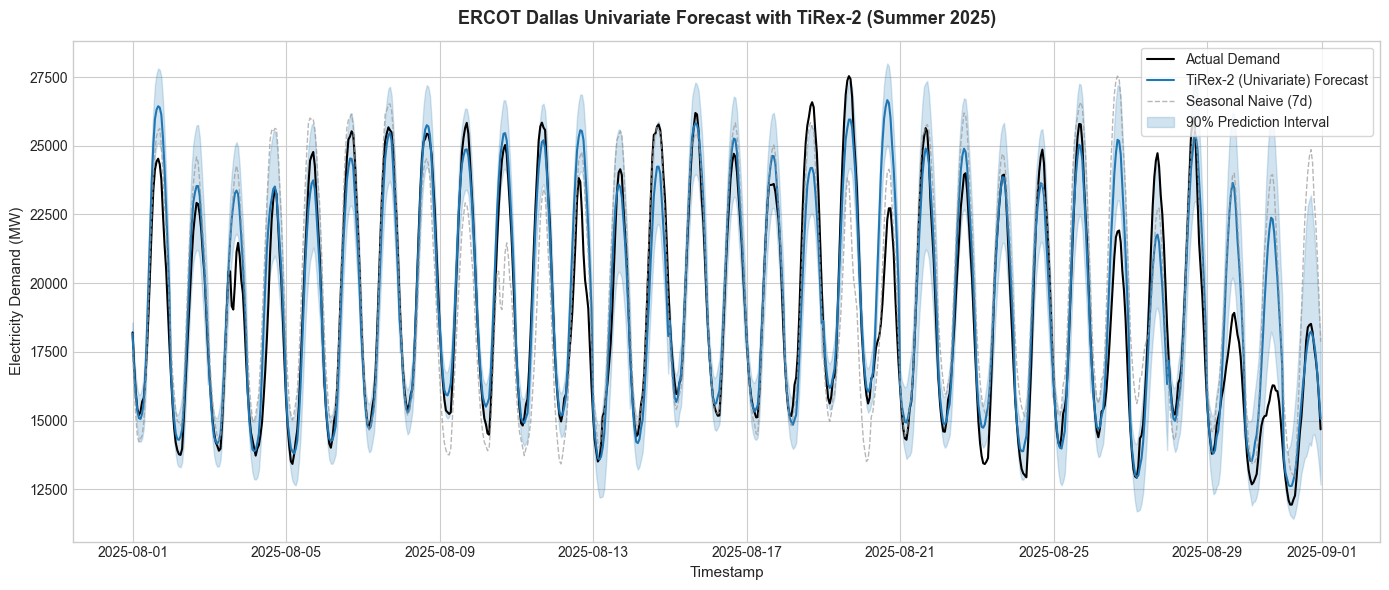

In [8]:
plt.figure(figsize=(14, 6))

# Plot full evaluation period actuals vs predictions
plt.plot(eval_df["timestamp"], eval_df["actual"], label="Actual Demand", color="black", lw=1.5)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="TiRex-2 (Univariate) Forecast", color="#1f77b4", lw=1.5)
plt.plot(eval_df["timestamp"], eval_df["seasonal_naive"], label="Seasonal Naive (7d)", color="#999999", linestyle="--", lw=1.0, alpha=0.7)

# 90% Prediction interval
plt.fill_between(
    eval_df["timestamp"],
    eval_df["0.05"],
    eval_df["0.95"],
    color="#1f77b4",
    alpha=0.2,
    label="90% Prediction Interval"
)

plt.title("ERCOT Dallas Univariate Forecast with TiRex-2 (Summer 2025)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Timestamp", fontsize=11)
plt.ylabel("Electricity Demand (MW)", fontsize=11)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()
